In [39]:
# RUN THIS CELL FIRST
import os
import math
from collections import OrderedDict, Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.transforms import v2

import numpy as np
from numpy import allclose, isclose

from collections.abc import Callable
from sklearn.model_selection import train_test_split

TRAIN_PATH = "data/train"
VAL_PATH = "data/val"
TEST_PATH = "data/test"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
transformations = transforms.Compose(
    [
        v2.Resize((128,128)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomHorizontalFlip(),
        v2.RandomCrop((112,112)),
        v2.RandomAdjustSharpness(2),
        v2.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])
    ]
)

val_transformation = transforms.Compose(
    [
        v2.Resize((128,128)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])
    ]
)

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transformations)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=val_transformation)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_transformation)

class_labels = list(train_dataset.class_to_idx.keys())
indices = list(range(len(train_dataset)))
labels = [y for _, y in train_dataset]
class_counts = Counter(labels)
weights = [1 / class_counts[i] for i in labels]
print(weights)
num_classes = torch.unique(torch.tensor(labels))

cuda
[0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.0007575757575757576, 0.000

In [40]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers = 4)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=True)

In [41]:
print(len(weights))


15549


In [42]:
def get_accuracy(scores: torch.Tensor, labels: torch.Tensor) -> int | float:
    _, predictions = torch.max(scores, 1)
    # Per-class accuracy breakdown
    classes = torch.unique(labels)
    for cls in classes:
        mask = labels == cls
        cls_acc = (predictions[mask] == labels[mask]).float().mean().item()
        print(f"Class {class_labels[cls.item()]}: {cls_acc:.2%}")
    
    overall = (predictions == labels).float().mean().item()
    print(f"Overall: {overall:.2%}")
    return overall

In [43]:
def train_model(model: nn.Module, dataloader: DataLoader, epochs: int = 20):
    """
    Trains the model for a specified number of epochs/iterations
    
    Parameters
    ---------- 
        model: A PyTorch model to be trained
        dataloader : A DataLoader object that provides batches of the training data
        epochs  : Number of epochs, default of 20
        
    Returns
    -------
        The final model and the loss curve (per epoch)
    """

    losses = []
    total = sum(class_counts.values())
    class_weights = torch.tensor(
        [total / class_counts[i] for i in class_counts.keys()],
        dtype=torch.float32
    ).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    # Set model to training mode. 
    # See (https://stackoverflow.com/questions/60018578/what-does-model-eval-do-in-pytorch) if curious.
    model.train() 
    optimiser = torch.optim.SGD(model.parameters(), momentum=0.9, lr=0.01, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=10, gamma=0.1)
    # optimiser = torch.optim.AdamW(model.parameters())
    for i in range(epochs):
        epoch_loss = 0.0
        for x_batch, y_batch in dataloader:
            optimiser.zero_grad()
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_output = model(x_batch)
            loss = loss_fn(y_output, y_batch)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item()
        scheduler.step()
        print(f"Epoch {i+1}/{epochs}, Loss: {epoch_loss:.4f}")
        losses.append(epoch_loss)
        model.eval()
        with torch.no_grad():
            val_loss = 0
            y_total_output = []
            y_total = []
            for i, data in enumerate(test_loader):
                x, y = data
                x, y = x.to(device), y.to(device)
                y_output = model.predict_proba(x)
                y_total_output += y_output.tolist()
                y_total += y.tolist()
                val_loss += loss_fn(y_output, y).item()
            get_accuracy(torch.tensor(y_total_output), torch.tensor(y_total))
        print(f"Val Loss: {val_loss:.4f}")
        model.train()

    return model, losses

In [44]:
class TestCNN(nn.Module):
    def __init__(self, classes: int):
        super().__init__()
        self.conv = nn.Sequential(
                        nn.Conv2d(3, 32, (3,3), padding=1),
                        nn.LeakyReLU(0.1),
                        nn.MaxPool2d((2,2)),
                        nn.Dropout(0.5),
                        nn.Conv2d(32, 64, (3,3), padding=1),
                        nn.LeakyReLU(0.1),
                        nn.MaxPool2d((2,2)),
                        nn.Dropout(0.5),
                        nn.Conv2d(64, 128, (3,3), padding=1),
                        nn.LeakyReLU(0.1),
                        nn.MaxPool2d((2,2)),
                        nn.Dropout(0.5),
                        nn.Conv2d(128, 256, (3,3), padding=1),
                        nn.LeakyReLU(0.1),
                        nn.MaxPool2d((2,2)),
                        nn.Dropout(0.5),
                        nn.Conv2d(256, 512, (3,3), padding=1),
                        nn.LeakyReLU(0.1),
                        nn.MaxPool2d((2,2)),
                        nn.Dropout(0.5),
                    )

        self.fc = nn.Sequential(
                        nn.Linear(512, 256),
                        nn.LeakyReLU(0.1),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(0.1),
                        nn.Dropout(0.5),
                        nn.Linear(128, classes),
                    )
        self.gap = nn.AdaptiveAvgPool2d(1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ YOUR CODE HERE """
        x = self.conv(x)
        """ YOUR CODE END HERE """
        x = self.gap(x) # GAP – do not remove this line
        """ YOUR CODE HERE """
        x = x.view(x.shape[0], -1)
        out = self.fc(x)
        """ YOUR CODE END HERE """
        return out
    
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        out = self.forward(x)
        return torch.softmax(out, dim = 1)

In [45]:
test_model, test_losses = train_model(TestCNN(14).to(device), train_loader, epochs = 50)

Epoch 1/50, Loss: 319.2853
Class boots: 0.00%
Class box: 0.00%
Class coin: 37.43%
Class exit: 0.00%
Class floor: 0.00%
Class gem: 0.00%
Class ghost: 0.00%
Class human: 29.58%
Class key: 34.55%
Class lava: 0.00%
Class locked: 94.55%
Class opened: 0.00%
Class shield: 0.00%
Class wall: 0.00%
Overall: 18.27%
Val Loss: 21.0956
Epoch 2/50, Loss: 283.2487
Class boots: 0.00%
Class box: 0.00%
Class coin: 0.00%
Class exit: 0.00%
Class floor: 0.00%
Class gem: 55.61%
Class ghost: 0.00%
Class human: 15.00%
Class key: 0.00%
Class lava: 0.00%
Class locked: 100.00%
Class opened: 0.00%
Class shield: 0.00%
Class wall: 0.00%
Overall: 15.74%
Val Loss: 20.8801
Epoch 3/50, Loss: 250.6602
Class boots: 70.91%
Class box: 8.45%
Class coin: 95.72%
Class exit: 5.45%
Class floor: 0.00%
Class gem: 0.53%
Class ghost: 77.54%
Class human: 3.75%
Class key: 6.67%
Class lava: 0.00%
Class locked: 28.48%
Class opened: 0.00%
Class shield: 17.61%
Class wall: 0.00%
Overall: 28.64%
Val Loss: 20.4629
Epoch 4/50, Loss: 217.4292


In [47]:
torch.save(test_model.state_dict(), "model_weights.pth")

In [48]:
test_model = torch.load("model_weights.pth")

In [38]:
test_model, test_losses2 = train_model(test_model, train_loader, epochs = 50)
test_losses += test_losses2

Epoch 1/50, Loss: 131.4193
Class boots: 3.03%
Class box: 97.89%
Class coin: 64.17%
Class exit: 89.09%
Class floor: 100.00%
Class gem: 74.87%
Class ghost: 0.00%
Class human: 77.50%
Class key: 49.70%
Class lava: 100.00%
Class locked: 48.48%
Class opened: 12.30%
Class shield: 45.07%
Class wall: 100.00%
Overall: 51.19%
Val Loss: 18.2925
Epoch 2/50, Loss: 100.3908
Class boots: 78.79%
Class box: 86.62%
Class coin: 55.08%
Class exit: 66.06%
Class floor: 100.00%
Class gem: 97.86%
Class ghost: 44.39%
Class human: 75.42%
Class key: 61.21%
Class lava: 100.00%
Class locked: 18.18%
Class opened: 16.58%
Class shield: 63.38%
Class wall: 0.00%
Overall: 60.27%
Val Loss: 18.0091
Epoch 3/50, Loss: 64.6741
Class boots: 10.91%
Class box: 82.39%
Class coin: 51.87%
Class exit: 85.45%
Class floor: 100.00%
Class gem: 75.40%
Class ghost: 82.35%
Class human: 82.50%
Class key: 63.64%
Class lava: 100.00%
Class locked: 29.70%
Class opened: 38.50%
Class shield: 78.87%
Class wall: 100.00%
Overall: 62.44%
Val Loss: 17

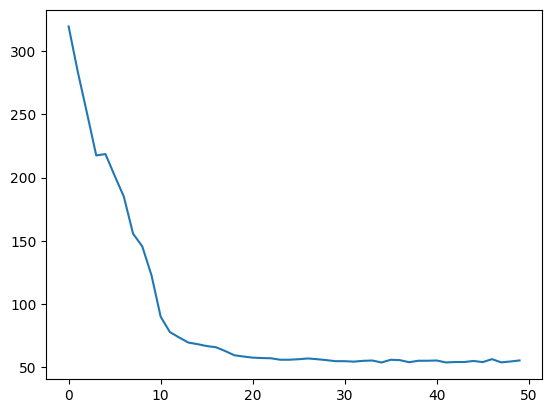

In [49]:
plt.plot(test_losses)

In [46]:
with torch.no_grad():
    test_model.eval()
    for i, data in enumerate(test_loader):
        x, y = data
        x, y = x.to(device), y.to(device)
        pred = test_model.predict_proba(x)
        acc = get_accuracy(pred, y)
        print(f"test accuracy: {acc}")

Class boots: 61.54%
Class box: 63.16%
Class coin: 82.14%
Class exit: 90.91%
Class floor: 100.00%
Class gem: 16.67%
Class ghost: 0.00%
Class human: 56.00%
Class key: 69.23%
Class lava: 100.00%
Class locked: 40.00%
Class opened: 5.00%
Class shield: 41.67%
Overall: 50.39%
test accuracy: 0.50390625
Class boots: 44.44%
Class box: 66.67%
Class coin: 89.47%
Class exit: 88.89%
Class gem: 35.71%
Class ghost: 0.00%
Class human: 70.27%
Class key: 68.42%
Class locked: 41.18%
Class opened: 8.33%
Class shield: 60.00%
Overall: 49.22%
test accuracy: 0.4921875
Class boots: 36.00%
Class box: 87.50%
Class coin: 84.00%
Class exit: 78.95%
Class gem: 41.67%
Class ghost: 0.00%
Class human: 55.26%
Class key: 43.48%
Class locked: 30.43%
Class opened: 0.00%
Class shield: 61.90%
Class wall: 100.00%
Overall: 47.27%
test accuracy: 0.47265625
Class boots: 42.86%
Class box: 64.71%
Class coin: 96.30%
Class exit: 95.65%
Class gem: 33.33%
Class ghost: 0.00%
Class human: 50.00%
Class key: 38.89%
Class locked: 40.00%
Cla

In [ ]:
from collections import Counter
labels = [label for _, label in train_set]
print(Counter(labels))


Counter({7: 1920, 6: 1500, 2: 1500, 11: 1500, 5: 1500, 8: 1320, 0: 1320, 10: 1320, 3: 1320, 12: 1140, 1: 1140, 4: 20, 13: 20, 9: 20})
